# Imports

In [1]:
from nb_utils import set_root
PROJECT_DIR = set_root(2)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import clear_output, display


# Parameters

In [3]:
path_data = PROJECT_DIR / "data"
path_intermediate = path_data / "02_intermediate"
path_primary = path_data / "03_primary"

file_path_data = path_primary / "tracker.parquet"
file_path_horm = path_intermediate / "data_horm_concat.parquet"
tracker_columns = ["tracker_id",	"class_id",	"x_min",	"y_min",	"x_max",	"y_max",	"x_center",	"y_center"]

# Read

In [4]:
data = pd.read_parquet(file_path_data)
data_horm = pd.read_parquet(file_path_horm)
data.head()

,tracker_id,class_id,x_min,y_min,x_max,y_max,ID,x_center,y_center
0,0,0,81.517593,341.390228,98.150589,358.730377,6,89.834091,350.060303
1,1,0,220.177231,32.698105,235.510880,48.191841,6,227.844055,40.444973
2,2,0,501.025208,244.382629,518.151794,260.651978,6,509.588501,252.517303
3,3,0,168.232040,412.327515,191.797409,435.265625,6,180.014725,423.796570
4,4,0,445.648376,83.616653,466.867371,104.786850,6,456.257874,94.201752


In [5]:
data["ID"] = data["ID"].astype(int)
data = data.set_index("ID")

# Example: ID = 35

In [6]:
data_filter = data[data.index == 35].copy()

In [7]:
35 in data.index.unique()

True

## Viz

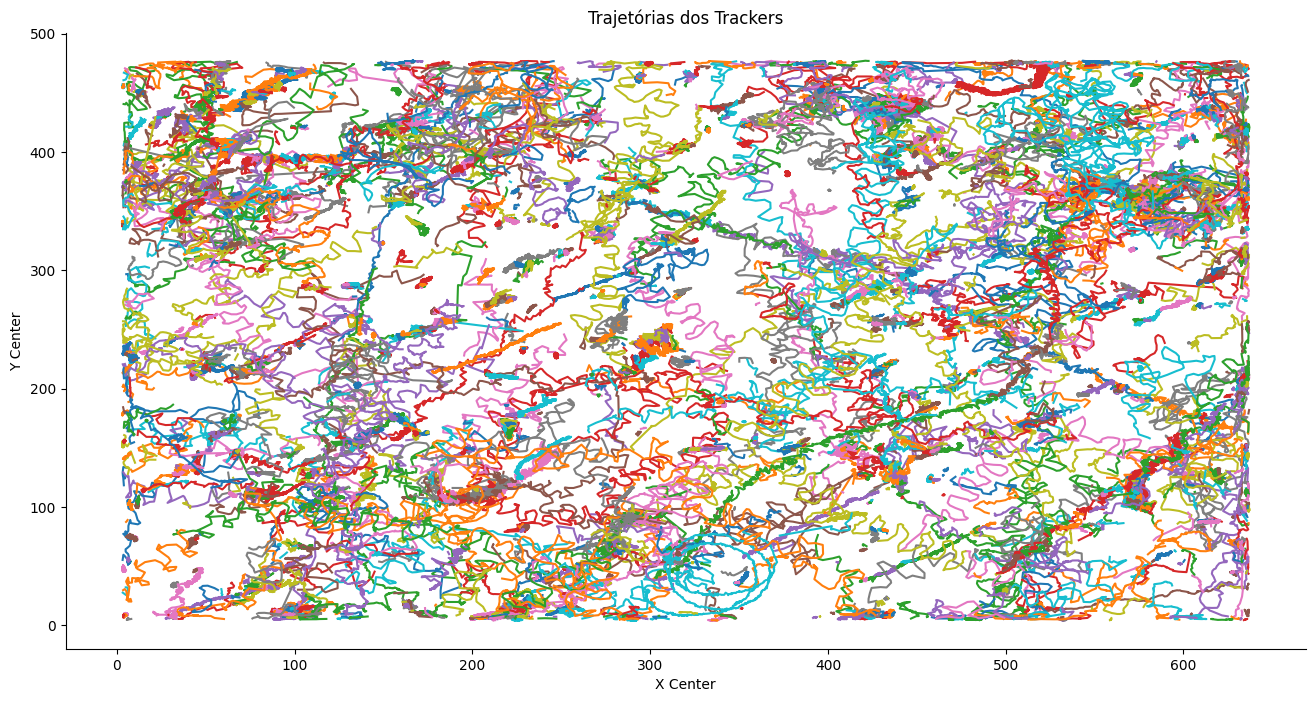

In [8]:
unique_tracker_ids = data_filter["tracker_id"].unique()

fig, ax = plt.subplots(1, 1, figsize=(16, 8))

for id_tracker in unique_tracker_ids:
    data_id = data_filter[data_filter["tracker_id"] == id_tracker]
    ax.plot(data_id["x_center"], data_id["y_center"], label=f"Tracker ID: {id_tracker}")

# Configurações do gráfico
ax.set_title("Trajetórias dos Trackers")
ax.set_xlabel("X Center")
ax.set_ylabel("Y Center")
ax.spines[["top", "right"]].set_visible(False)
#ax.legend()  # Adiciona a legenda
plt.show()

In [9]:
# Widget dropdown para selecionar a classe
classe_dropdown = widgets.Dropdown(
    options=data_filter["tracker_id"].unique(),
    description="Classe:"
)

# Função para gerar o scatter plot com base na classe selecionada
def plot_scatter(classe):
    clear_output(wait=True)  # Limpa a saída antes de gerar um novo gráfico
    display(classe_dropdown)  # Redesenha o dropdown
    filtered_df = data_filter[data_filter["tracker_id"] == classe]
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=filtered_df["x_center"],
        y=filtered_df["y_center"],
        mode="lines+markers",
        marker=dict(size=10),
        name=f"Classe {classe}"
    ))
    fig.update_layout(
        title=f"Scatter Plot para Classe {classe}",
        xaxis_title="Eixo X",
        yaxis_title="Eixo Y",
        showlegend=True,
        height=600
    )
    fig.show()

# Exibe o dropdown e inicializa a interação
display(classe_dropdown)
classe_dropdown.observe(lambda change: plot_scatter(change["new"]), names="value")

Dropdown(description='Classe:', options=(np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.i…

# Comparison

In [10]:
unique_ids = [64, 78, 29, 85]#[82, 14, 29, 52] #[35, 19, 38, 24]  #[47, 35, 36, 82]#list(data.index.unique())[:2]

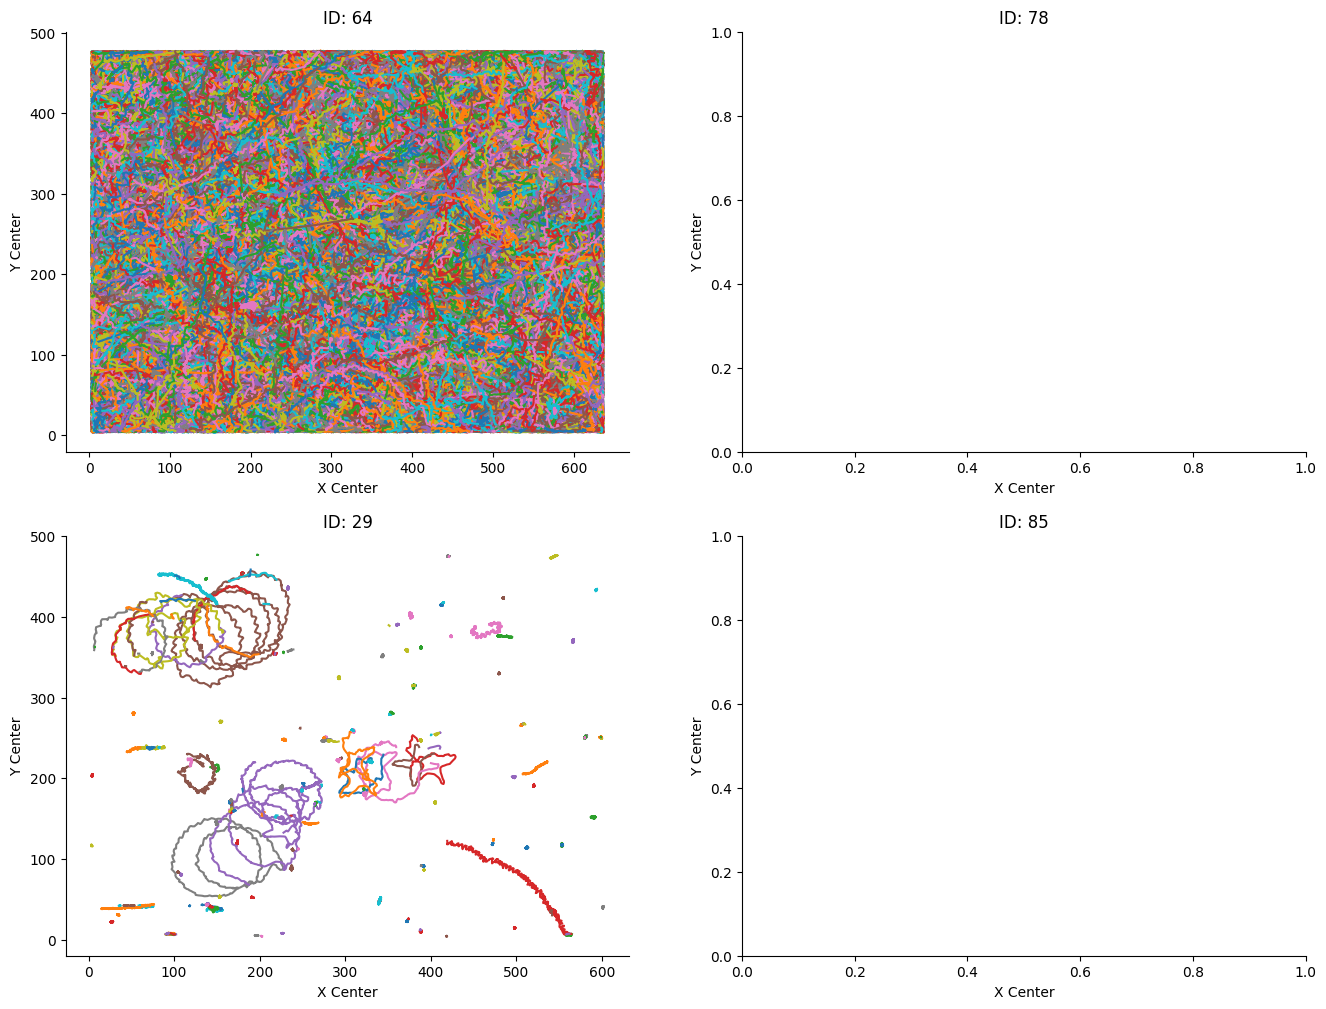

In [11]:
fig, ax = plt.subplots(len(unique_ids) // 2, 2, figsize=(16, 12))
if isinstance(ax, np.ndarray):
    ax = ax.flatten()
for id_instance, _ax in zip(unique_ids, ax):
    data_filter = data[data.index == id_instance].copy()
    unique_tracker_ids = data_filter["tracker_id"].unique()
    for id_tracker in unique_tracker_ids:
        data_id = data_filter[data_filter["tracker_id"] == id_tracker]
        _ax.plot(data_id["x_center"], data_id["y_center"], label=f"Tracker ID: {id_tracker}")

    # Configurações do gráfico
    _ax.set_title(f"ID: {id_instance}")
    _ax.set_xlabel("X Center")
    _ax.set_ylabel("Y Center")
    _ax.spines[["top", "right"]].set_visible(False)
    #_ax.legend()  # Adiciona a legenda
    #plt.show()

In [12]:
data_horm.loc[unique_ids, :].drop_duplicates()[["Total sperm count", "Seminal AMH"]]

,Total sperm count,Seminal AMH
ID,,
64,668.7,8.0
78,561.0,1674.0
29,20.0,1.0
85,496.8,4105.0


In [13]:
data[["ID"] + tracker_columns].reset_index().drop(["tracker_id", "class_id"], axis=1).groupby("ID").var().idxmin()

KeyError: "['ID'] not in index"

In [ ]:
data[["ID"] + tracker_columns].reset_index().drop(["tracker_id", "class_id"], axis=1).groupby("ID").var().idxmax()

In [ ]:
data_horm.loc[unique_ids, :].drop_duplicates()[["Total sperm count", "Seminal AMH", "BMI", "Age"]]

In [ ]:
# import matplotlib.pyplot as plt
#  # Define a posição dos nós
# k = 4
# i_graph = graphs[k]
# pos = nx.spring_layout(i_graph)

# # Desenha o grafo
# plt.figure(figsize=(10, 8))
# nx.draw(i_graph, pos, with_labels=True, node_color='skyblue', font_size=5, font_weight='bold')

# # Desenha as arestas com largura proporcional ao peso
# edges = i_graph.edges(data=True)
# nx.draw_networkx_edges(i_graph, pos, edgelist=edges, width=[d['weight_inv'] for (u, v, d) in edges])

# plt.title(f'Grafo para o Livro {k}')
# plt.show()